# 7-2 임베딩을 사용하는 순환 신경망 모델

본 노트북은 7-2 절 본문의 [코드 7-2] ~ [코드 7-5] 예제와 본문이 깃허브 노트북에 미룬 다음 항목들을 모두 포함한다.

- `[코드 7-2]` `nn.Embedding` 임베딩 계층 생성
- `[코드 7-3]` `OzWriter` 모델 정의 (임베딩 + LSTM + 완전 연결)
- 데이터 전처리 (오즈의 마법사 텍스트 정제 + 토큰화)
- `[코드 7-4]` `OzDataset` 클래스, 어휘 사전, 데이터로더
- `[코드 7-5]` 모델 학습 환경 (임베딩 차원, 은닉 크기, 옵티마이저)
- 학습 루프 + 학습 곡선 ([그림 7-7])
- 마중물 텍스트로부터 문장 생성 함수 ([표 7-1])
- 대조군 `OzRawWriter` (임베딩 미사용) 정의/학습 및 비교

> 소설 '오즈의 마법사' 텍스트는 깃허브 저장소 규약(§13.9)에 따라 `'../../data/wonderful_wizard_of_oz.txt'` 로 읽는다.

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

torch, numpy 는 기본 의존성으로 README 에서 안내한다. 별도 설치가 필요하면 아래를 사용한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q numpy torch 

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [3]:
# 참고 - 라이브러리 import 와 시드 고정
# import random
# import re
# import time
# from collections import Counter
# from pathlib import Path

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import torch.optim as optim
# from torch.utils.data import DataLoader, Dataset

common.set_seed()
device = common.get_device()

CUDA를 사용합니다.


## [코드 7-2] 임베딩 계층 생성

`nn.Embedding(num_embeddings, embedding_dim)` 으로 임베딩 계층을 생성한다. `embeddings.weight` 는 `(num_embeddings, embedding_dim)` 형태의 임베딩 행렬이다.

In [4]:
###############################################################################
# 코드 7-2 - 임베딩 계층 생성
###############################################################################
import torch.nn as nn

# 토큰을 임베딩 벡터로 인코딩하는 임베딩 계층
#   num_embeddings: 어휘 사전의 크기(고유한 토큰의 개수, 20)
#   embedding_dim: 임베딩 벡터의 차원(10)
embeddings = nn.Embedding(num_embeddings=20, embedding_dim=10)
# 인자를 순서대로 지정한 nn.Embedding(20, 10)와 같음

# embeddings.weight: 임베딩 계층의 가중치 텐서로 임베딩 행렬에 해당
print(embeddings.weight.shape)      

torch.Size([20, 10])


임베딩 행렬의 각 행은 한 토큰에 대응하는 임베딩 벡터이다. 처음에는 무작위 값으로 초기화되며, 모델 학습 과정에서 손실 기반의 역전파로 최적화된다.

## [코드 7-3] 임베딩 계층을 사용하는 LSTM 모델

`OzWriter` 는 임베딩 계층 → LSTM 계층 → 완전 연결 계층으로 구성된다.
- 입력: `(B, S)` 형태의 토큰 고유 번호 텐서 (원-핫 인코딩 없음)
- 임베딩 후 형태: `(B, S, D)` (D = 임베딩 벡터의 크기)
- LSTM 출력: `(B, S, hidden_size)` — 마지막 위치 `[:, -1, :]` 만 사용
- 최종 출력: `(B, V)` 의 로짓 (V = 어휘 사전의 크기)

In [5]:
###############################################################################
# 코드 7-3 - 임베딩 계층을 사용하는 LSTM 모델
###############################################################################
# 소설을 학습해, 마중물 텍스트의 다음 토큰을 예측하는 순환 신경망 모델 클래스
#     임베딩 계층, LSTM 계층, 완전 연결 계층으로 구성
class OzWriter(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        # 임베딩 계층
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        # LSTM 계층: input_size는 임베딩 벡터의 크기(embedding_dim)를 사용
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        # 완전 연결 계층
        self.fc = nn.Linear(hidden_size, vocab_size)

# B: 배치 크기, S: 입력 샘플의 길이, D: 임베딩 벡터의 크기, V: 어휘 사전의 크기    
    def forward(self, x):               # x: (B, S)
        x = self.embeddings(x)          #    -> (B, S, D)
        x, _ = self.lstm(x)             #    -> (B, S, hidden_size)
        x = x[:, -1, :]                 #    -> (B, hidden_size)
        return self.fc(x)               #    -> (B, V)

## 참고 - 오즈의 마법사 텍스트 로딩과 전처리

본문은 "모든 알파벳을 소문자로 바꾼 뒤, 공백 문자·소문자 알파벳·쉼표·마침표·느낌표·물음표·아포스트로피를 제외한 모든 문자를 삭제" 한다고 안내한다. 토큰화 단계에서는 쉼표/마침표/느낌표/물음표를 별도 토큰으로 분리하고 아포스트로피는 단어를 구성하는 글자로 취급한다.

본문은 깃허브 노트북에 데이터 전처리 코드를 두므로, 본 노트북에서는 동일한 결과를 내도록 정규식으로 전처리한다.

In [6]:
# 참고 - 오즈의 마법사 텍스트 로딩 (Chapter I 본문 추출)
import re
from pathlib import Path

raw = Path('../../data/wonderful_wizard_of_oz.txt').read_text(
    encoding='utf-8-sig',
)

# 본문 시작은 줄바꿈 뒤의 'Chapter I' 줄 패턴. 그 앞은 목차이므로 건너뜀.
match = re.search(r'\nChapter I\n', raw)
start = match.start() if match else raw.find('Chapter I')
end = raw.rfind('*** END OF THE PROJECT GUTENBERG')
if end == -1:
    end = raw.rfind('THE END')
text = raw[start:end].strip()
print(f'본문 길이: {len(text):,}자')
print(f'본문 시작 80자: {text[:80]!r}')

본문 길이: 205,490자
본문 시작 80자: 'Chapter I\nThe Cyclone\n\n\nDorothy lived in the midst of the great Kansas prairies,'


In [7]:
# 참고 - 텍스트 정제와 토큰화
# 1) 소문자 변환
# 2) 알파벳, 공백, 쉼표/마침표/느낌표/물음표, 아포스트로피만 남김
#    (오즈 텍스트는 곱슬 아포스트로피를 사용하므로 두 종류 모두 허용)
# 3) 쉼표/마침표/느낌표/물음표는 별도 토큰으로, 아포스트로피는 단어에 포함
APOS = '’'                          # 곱슬 아포스트로피 문자
normalized = text.lower()
# 허용 문자 외에는 모두 공백으로 치환 (이후 토큰화로 통합)
normalized = re.sub(f"[^a-z\\s,.!?{APOS}']", ' ', normalized)
# 단어 단위 토큰과 부호 토큰을 정규식으로 추출
tokens = re.findall(f"[a-z{APOS}']+|[,.!?]", normalized)
# 단어 끝의 닫는 홑따옴표 제거 (본문 각주 11 참고)
tokens = [t.rstrip(APOS) if not t.endswith("'") else t for t in tokens]
# 닫는 따옴표만으로 구성되어 빈 문자열이 된 토큰 제거
tokens = [t for t in tokens if t]

print(f'전체 토큰 수: {len(tokens):,}')
print(f'고유 토큰 수: {len(set(tokens)):,}')
print(f'처음 20 토큰: {tokens[:20]}')

전체 토큰 수: 44,299
고유 토큰 수: 2,902
처음 20 토큰: ['chapter', 'i', 'the', 'cyclone', 'dorothy', 'lived', 'in', 'the', 'midst', 'of', 'the', 'great', 'kansas', 'prairies', ',', 'with', 'uncle', 'henry', ',', 'who']


본문도 전체 44,299 토큰, 고유 2,902 토큰으로 노트북 결과와 일치한다. (텍스트 정제 정규식이 달라지면 토큰 수가 조금 바뀔 수 있으나, 자릿수가 비슷하면 후속 학습 결과도 유사하게 나온다.)

## [코드 7-4] 어휘 사전, OzDataset, 데이터로더

`OzDataset` 은 토큰 고유 번호의 리스트를 받아 슬라이딩 윈도우 방식으로 (입력 시퀀스, 다음 토큰 정답) 샘플을 만든다.

> 컨벤션 정리: 본문은 데이터셋을 `dataset`, 데이터로더를 `dataloader` 로 명명하지만, §3.2 에 따라 노트북에서는 `train_set` / `train_loader` 로 통일한다. 본문 변수 `sequence_length`, `batch_size` 는 §4.1 에 따라 모듈 레벨 상수 `SEQUENCE_LENGTH`, `BATCH_SIZE` 로 둔다. (단 클래스 인자명은 소문자 유지.)

In [8]:
# 참고 - 어휘 사전의 생성
# 어휘 사전: 가나다순으로 정렬된 토큰에 0부터 고유 번호 부여
vocab = {t: i for i, t in enumerate(sorted(set(tokens)))}
vocab_size = len(vocab)

In [9]:
###############################################################################
# 코드 7-4 - 어휘 사전, 데이터셋과 데이터로더 생성
###############################################################################
import torch
from torch.utils.data import DataLoader, Dataset

# 토큰 리스트에서 입력 샘플과 정답의 쌍을 구성하는 데이터셋 클래스
class OzDataset(Dataset):
    def __init__(self, token_idxs, sequence_length):
        self.token_idxs = token_idxs            # 토큰 고유 번호의 리스트
        self.sequence_length = sequence_length  # 입력 샘플의 길이

    def __len__(self):
        # (입력, 정답) 샘플의 수
        return len(self.token_idxs) - self.sequence_length

    def __getitem__(self, idx):
        # 임베딩 계층에 입력할 텐서이므로 원-핫 인코딩하지 않음
        # 입력 샘플: sequence_length 개의 토큰 고유 번호
        x = torch.tensor(
            self.token_idxs[idx: idx + self.sequence_length],
            dtype=torch.long
        )
        # 정답 샘플: 입력 다음 토큰의 고유 번호
        y = torch.tensor(
            self.token_idxs[idx + self.sequence_length],
            dtype=torch.long,
        )
        return x, y


# token_idxs: 전처리 과정을 마친 정제 리스트 (토큰의 순차 데이터)
#             토큰을 고유 번호 시퀀스로 변환
token_idxs = [vocab[t] for t in tokens]

# 데이터셋 생성 - 20 개의 토큰으로 하나의 입력 샘플 구성
SEQUENCE_LENGTH = 20                                  
dataset = OzDataset(token_idxs, SEQUENCE_LENGTH)

# 데이터로더 생성
BATCH_SIZE = 64                                       
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'데이터셋의 샘플 수: {len(dataset)}')          
print(f'입력 샘플 텐서의 형태: {tuple(dataset[0][0].shape)}') 
print(f'입력 샘플의 자료형: {dataset[0][0].dtype}')

데이터셋의 샘플 수: 44279
입력 샘플 텐서의 형태: (20,)
입력 샘플의 자료형: torch.int64


입력 샘플 텐서의 형태와 자료형에서 확인할 수 있듯, 이전의 순환 신경망 모델의 데이터셋과 달리 입력 샘플로 원-핫 인코딩 텐서가 아니라 토큰의 고유 번호를 그대로 사용한다. `nn.Embedding` 객체가 인코딩되지 않은 고유 번호를 그대로 입력받기 때문이다.

## [코드 7-5] 모델 학습 환경 설정

In [ ]:
###############################################################################
# 코드 7-5 - 모델 학습 환경 설정
###############################################################################
import torch.optim as optim

# 하이퍼파라미터
EMBEDDING_DIM = 128         # 임베딩 차원의 크기
HIDDEN_SIZE = 128           # LSTM 의 숨겨진 상태 텐서의 크기
LR = 0.001                  # 학습률

# 모델 객체, 손실 함수, 옵티마이저 생성
model = OzWriter(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [11]:
# 참고 - 문장 생성 함수
def make_sentence(model, prompt_tokens, vocab, idx_to_token,
                  sequence_length, num_generate, device):
    '''prompt_tokens 뒤에 num_generate 개의 토큰을 차례로 예측해 잇는다.'''
    # 어휘 사전에 없는 토큰은 제외해 KeyError 를 회피
    safe = [t for t in prompt_tokens if t in vocab]
    if len(safe) < sequence_length:
        # 부족하면 앞쪽을 첫 토큰으로 채워 길이를 맞춤
        pad = [list(vocab.keys())[0]] * (sequence_length - len(safe))
        safe = pad + safe

    generated = list(safe)
    model.eval()
    with torch.no_grad():
        for _ in range(num_generate):
            # 마지막 sequence_length 토큰만 입력으로 사용
            window = generated[-sequence_length:]
            x = torch.tensor(
                [[vocab[t] for t in window]],
                dtype=torch.long, device=device,
            )
            logits = model(x)                          # (1, V)
            next_idx = torch.argmax(logits, dim=1).item()
            generated.append(idx_to_token[next_idx])
    # 생성된 부분만 반환
    return generated[len(safe):]

# 고유 번호 -> 토큰 역인덱스
idx_to_token = {i: t for t, i in vocab.items()}

# [표 7-1] 의 마중물 텍스트 (쉼표 앞 공백 = 별도 토큰)
prompt_text = (
    'dorothy , lion and scarecrow really worried about the emerald city , '
    'but oz said the city is safe because'
)
prompt_tokens = prompt_text.split()
print(f'마중물 토큰 수: {len(prompt_tokens)} (>= sequence_length=20)')


oz_writer_results = []
oz_raw_writer_results = []

마중물 토큰 수: 20 (>= sequence_length=20)


## 참고 - 학습 함수 정의

본문은 OzWriter 학습 코드를 "다른 순환 신경망 모델과 같은 방식" 으로 표현해 별도로 보여주지 않는다. 컨벤션 §7 의 분해 패턴(`train_epoch` / `train_loop`) 으로 학습 함수를 정의한다. 검증 데이터셋은 본문이 사용하지 않으므로 단순 학습 함수만 둔다(연습 7-5 에서 검증 분리 버전을 따로 만든다).

epoch    훈련 손실     시간
 1/30       5.5772     0:04
 3/30       4.3300     0:09
 6/30       3.5343     0:17
 9/30       2.9353     0:24
12/30       2.4354     0:32
15/30       2.0168     0:40
18/30       1.6661     0:48
21/30       1.3712     0:56
24/30       1.1214     1:03
27/30       0.9132     1:11
30/30       0.7409     1:19
---------------------------
전체 학습 시간 1:19


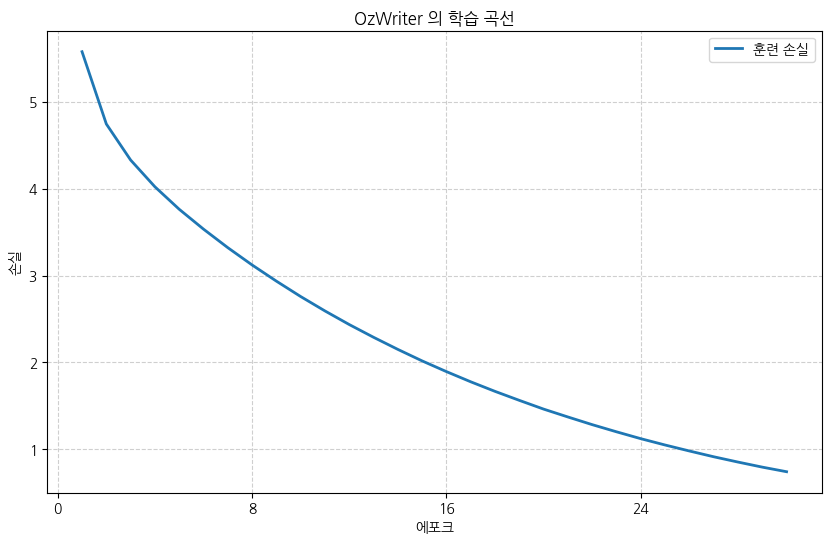

[', and the scarecrow was a great . the scarecrow , and the scarecrow was a great . the scarecrow , and the scarecrow was a great . the scarecrow', 'i am a good witch , said the scarecrow . i am not , said the scarecrow . i am not , said the scarecrow . i am not ,', 'you are a great wizard , and i am sure i am sure i am sure i am sure i am sure i am sure i am sure i am', 'you are all wrong . but the scarecrow and the tin woodman and the lion and the lion and the lion and the lion whispered to the throne room and', 'you are all wrong , and i’m sure we shall not know what ? we must protect him ourselves if he is a great spring , and then you will', 'you are all we can for me . i want him to give me some brains , said the scarecrow . you see , if you will help us to', 'you are wise . but i thought oz was a terrible beast , said the tin woodman . and i shall never have brains , added the scarecrow . and']


In [12]:
# 참고 - 학습 함수 정의 (train_epoch + train_loop)
def train_epoch(model, train_loader, criterion, optimizer, device):
    '''1 에포크 학습 - 기울기 클리핑을 적용하고 가중 평균 훈련 손실을 반환.'''
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        # 기울기 클리핑 - LSTM 의 기울기 폭주 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size


def train(model, train_loader, criterion, optimizer, epochs, device, title='학습 곡선', results=None):
    '''여러 에포크에 걸친 학습 루프. 학습 로그를 담은 EpochLogger를 반환.

    본문이 검증 손실을 다루지 않으므로 훈련 손실 한 열만 기록한다. 손실 이력은
    log.history['훈련 손실'] 로 다시 꺼내 두 모델의 학습 곡선 비교에 쓴다.
    '''
    model.to(device)
    # 검증이 없는 생성형 학습이므로 훈련 손실 한 열만 기록한다(§7.6).
    log = common.EpochLogger(epochs, columns=('훈련 손실',), formats=('{:.4f}',))
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        log.row(epoch, train_loss)
        if results is not None and (epoch % 5 == 0 or epoch == 1):
            # 5 에포크마다 마중물 텍스트로 문장 생성해 출력
            generated = make_sentence(
                model, prompt_tokens, vocab, idx_to_token,
                SEQUENCE_LENGTH, num_generate=30, device=device,
            )

            results.append(' '.join(generated))
    log.summary()                       # 최적 에포크 + 전체 학습 시간
    log.plot(title=title)               # 학습 곡선(항상)
    return log


# OzWriter 학습 (30 에포크)
EPOCHS = 30
log_oz = train(
    model, dataloader, criterion, optimizer, EPOCHS, device,
    title='OzWriter 의 학습 곡선',
    results=oz_writer_results,
)
print(oz_writer_results)

## 참고 - 마중물 텍스트로부터 문장 생성

본문 [표 7-1] 에 사용된 마중물("dorothy , lion and scarecrow really worried about the emerald city , but oz said the city is safe because") 로 30 개의 토큰을 차례로 예측해 잇는 생성 함수를 정의한다.

본문 각주 12 에서 "입력 텍스트에 쉼표 앞에 공백이 추가되어 있는데, 이는 마침표/느낌표/물음표와 함께 쉼표를 별도의 토큰으로 사용하고 있기 때문" 이라고 안내한다.

In [13]:
# 고유 번호 -> 토큰 역인덱스
idx_to_token = {i: t for t, i in vocab.items()}

# [표 7-1] 의 마중물 텍스트 (쉼표 앞 공백 = 별도 토큰)
prompt_text = (
    'dorothy , lion and scarecrow really worried about the emerald city , '
    'but oz said the city is safe because'
)
prompt_tokens = prompt_text.split()
print(f'마중물 토큰 수: {len(prompt_tokens)} (>= sequence_length=20)')

generated = make_sentence(
    model, prompt_tokens, vocab, idx_to_token,
    SEQUENCE_LENGTH, num_generate=30, device=device,
)
print('--- OzWriter 30 에포크 생성 결과 ---')
print(' '.join(generated))

마중물 토큰 수: 20 (>= sequence_length=20)
--- OzWriter 30 에포크 생성 결과 ---
you are wise . but i thought oz was a terrible beast , said the tin woodman . and i shall never have brains , added the scarecrow . and


위 출력은 [표 7-1] 의 30 에포크 OzWriter 생성 결과에 해당한다. "you are wise . but i thought oz was a terrible beast , said the tin woodman . and i shall never have brains , added the scarecrow ." 처럼 인물(양철나무꾼·허수아비)과 그 욕구(뇌)가 연결된 문장이 이어지는 것을 볼 수 있다. 시드·전처리 차이로 토큰이 달라질 수 있으나, 의미가 호응하는 흐름은 유사하게 관찰된다.

## 참고 - 대조군 OzRawWriter (임베딩 미사용)

본문은 "임베딩 계층의 효과를 확인하기 위한 대조군으로 임베딩 계층이 없는 OzRawWriter 클래스도 만들어 같은 데이터로 학습하는데, OzRawWriter 클래스의 정의 및 학습 과정은 본문에 싣지 않는다" 고 안내한다. 깃허브 노트북 역할인 본 노트북에서는 이를 직접 정의한다.

`OzRawWriter` 는 토큰 고유 번호 대신 원-핫 인코딩된 벡터를 LSTM 에 직접 입력한다. 데이터셋도 원-핫 인코딩 버전인 `OzRawDataset` 으로 새로 만든다.

In [17]:
# 참고 - OzRawWriter 와 OzRawDataset (임베딩 미사용 대조군)
import torch.nn.functional as F

class OzRawDataset(Dataset):
    '''OzDataset 과 같은 슬라이딩 윈도우. 입력은 (S, V) 원-핫 텐서.'''

    def __init__(self, token_idxs, sequence_length, vocab_size):
        self.token_idxs = token_idxs
        self.sequence_length = sequence_length
        self.vocab_size = vocab_size

    def __len__(self):
        return len(self.token_idxs) - self.sequence_length

    def __getitem__(self, idx):
        window = torch.tensor(
            self.token_idxs[idx: idx + self.sequence_length],
            dtype=torch.long,
        )
        x = F.one_hot(window, num_classes=self.vocab_size).float()
        y = torch.tensor(
            self.token_idxs[idx + self.sequence_length], dtype=torch.long,
        )
        return x, y


class OzRawWriter(nn.Module):
    '''임베딩 계층 없이 원-핫 입력을 직접 LSTM 으로 처리.'''

    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        # LSTM 의 input_size 는 vocab_size 와 같음
        self.lstm = nn.LSTM(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):                 # 입력 x: (B, S, V) 원-핫
        x, _ = self.lstm(x)               # (B, S, V) -> (B, S, hidden_size)
        x = x[:, -1, :]                   # (B, S, hidden_size) -> (B, hidden_size)
        return self.fc(x)                 # (B, hidden_size) -> (B, V)

In [ ]:
def make_sentence_raw(model, prompt_tokens, vocab, idx_to_token,
                      sequence_length, vocab_size, num_generate, device):
    safe = [t for t in prompt_tokens if t in vocab]
    generated = list(safe)
    model.eval()
    with torch.no_grad():
        for _ in range(num_generate):
            window = generated[-sequence_length:]
            idxs = torch.tensor(
                [vocab[t] for t in window], dtype=torch.long, device=device,
            )
            x = F.one_hot(idxs, num_classes=vocab_size).float().unsqueeze(0)
            logits = model(x)
            next_idx = torch.argmax(logits, dim=1).item()
            generated.append(idx_to_token[next_idx])
    return generated[len(safe):]



def train_loop_raw(model, train_loader, criterion, optimizer, epochs, device, title='학습 곡선', results=None):
    '''여러 에포크에 걸친 학습 루프. 학습 로그를 담은 EpochLogger를 반환.

    본문이 검증 손실을 다루지 않으므로 훈련 손실 한 열만 기록한다. 손실 이력은
    log.history['훈련 손실'] 로 다시 꺼내 두 모델의 학습 곡선 비교에 쓴다.
    '''
    model.to(device)
    # 검증이 없는 생성형 학습이므로 훈련 손실 한 열만 기록한다(§7.6).
    log = common.EpochLogger(epochs, columns=('훈련 손실',), formats=('{:.4f}',))
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        log.row(epoch, train_loss)
        if results is not None and (epoch % 5 == 0 or epoch == 1):
            # 5 에포크마다 마중물 텍스트로 문장 생성해 출력
            generated = make_sentence_raw(
                model, prompt_tokens, vocab, idx_to_token,
                SEQUENCE_LENGTH, len(vocab), num_generate=30, device=device,
            )

            results.append(' '.join(generated))
    log.summary()                       # 최적 에포크 + 전체 학습 시간
    log.plot(title=title)               # 학습 곡선(항상)
    return log


epoch    훈련 손실     시간
 1/30       5.9163     0:11
 3/30       4.8367     0:36
 6/30       4.0106     1:09
 9/30       3.4468     1:45
12/30       2.9214     2:21
15/30       2.4071     2:56
18/30       1.9275     3:34
21/30       1.4922     4:10
24/30       1.1253     4:44
27/30       0.8233     5:20
30/30       0.5848     5:56
---------------------------
전체 학습 시간 5:56


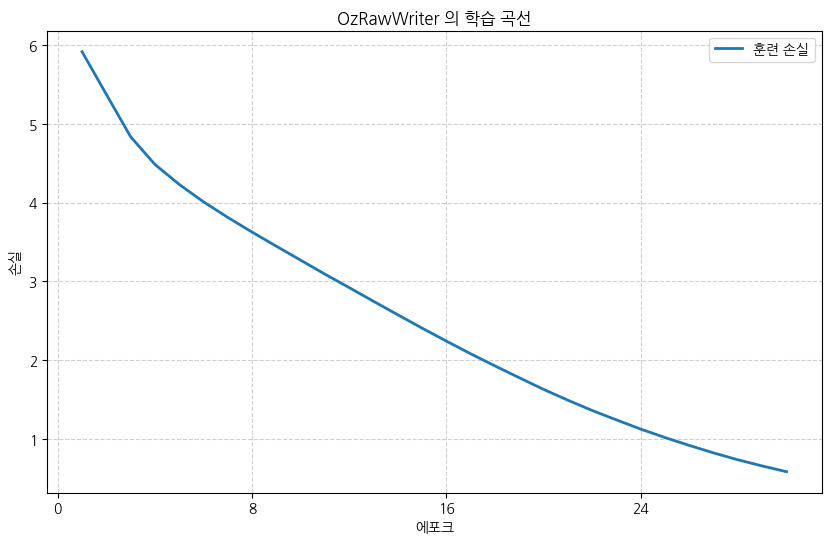

In [19]:
# 참고 - OzRawWriter 학습 (동일 시드로 재현)
common.set_seed()

raw_train_set = OzRawDataset(token_idxs, SEQUENCE_LENGTH, vocab_size)
raw_train_loader = DataLoader(
    raw_train_set, batch_size=BATCH_SIZE, shuffle=True,
)

model_raw = OzRawWriter(vocab_size, HIDDEN_SIZE).to(device)
criterion_raw = nn.CrossEntropyLoss()
optimizer_raw = optim.Adam(model_raw.parameters(), lr=LR)

log_oz_raw = train_loop_raw(
    model_raw, raw_train_loader, criterion_raw, optimizer_raw, EPOCHS, device,
    title='OzRawWriter 의 학습 곡선',
    results=oz_raw_writer_results,
)

In [ ]:
# 참고 - OzRawWriter 의 에포크별 생성 결과 누적 리스트
# (학습 루프가 results 인자로 1·5·10·15·20·25·30 에포크 시점의 생성 결과를 모은 것)
print(oz_raw_writer_results)

['the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the', 'the scarecrow , and i am a heart , and the scarecrow , and the scarecrow and the scarecrow and the scarecrow and the scarecrow and the scarecrow and the', 'the lion is a great wizard . i have never been brains , said the scarecrow . i have never been a heart . i will be a heart ,', 'the witch is the voice ? i am sure , answered the scarecrow . i am going to give me a heart , said the tin woodman . and i', 'the scarecrow is a coward . oh , yes , said the scarecrow . and i am a very kind , you are . there is no use to me', 'the great oz will not be well . i’m not afraid , my dear , you are of our , who had been to him . but is no ,', 'the queen oz is a great wizard . oh , yes , said the scarecrow , he is a coward . with tin woodman , and no one of one']


## 참고 - 두 모델의 학습 곡선 비교 ([그림 7-7])

본문 [그림 7-7] 은 OzWriter 와 OzRawWriter 의 학습 곡선을 비교한다. 본문 설명대로 초기에는 OzWriter 의 손실이 더 빠르게 떨어지고, 학습 후반(25 에포크 부근)에 이르면 차이가 좁혀지다 OzRawWriter 가 더 낮은 손실에 도달하기도 한다(과적합 신호).

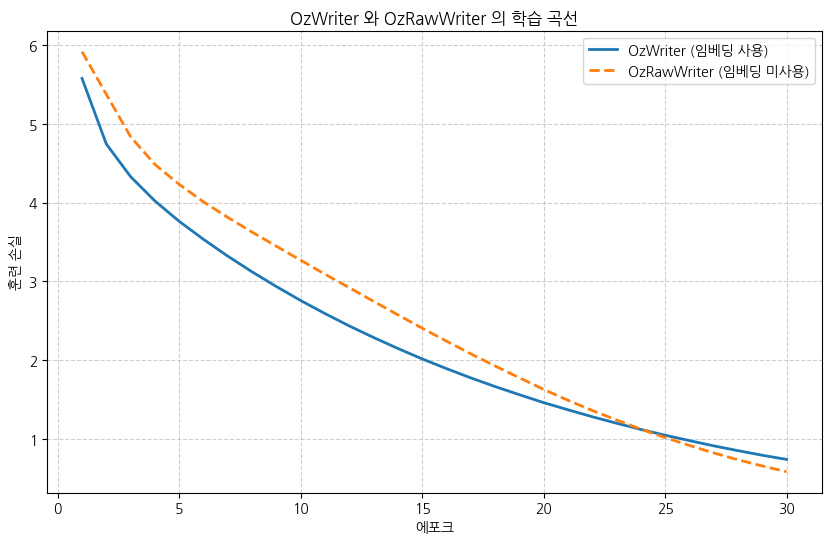

In [ ]:
# 참고 - 두 모델의 학습 곡선 비교 ([그림 7-7])
# 각 EpochLogger가 누적한 손실 이력(log.history)을 꺼내 한 그래프로 비교한다.
viz.plot_histories(
    {
        'OzWriter (임베딩 사용)': log_oz.history['훈련 손실'],
        'OzRawWriter (임베딩 미사용)': log_oz_raw.history['훈련 손실'],
    },
    title='OzWriter 와 OzRawWriter 의 학습 곡선',
    y_label='훈련 손실',
)

## 참고 - OzRawWriter 의 생성 결과 비교

같은 마중물로 OzRawWriter 의 생성 결과를 출력해 비교한다.

In [ ]:
# 참고 - OzRawWriter 마중물 생성 함수 (원-핫 입력용)
def make_sentence_raw(model, prompt_tokens, vocab, idx_to_token,
                      sequence_length, vocab_size, num_generate, device):
    safe = [t for t in prompt_tokens if t in vocab]
    generated = list(safe)
    model.eval()
    with torch.no_grad():
        for _ in range(num_generate):
            window = generated[-sequence_length:]
            idxs = torch.tensor(
                [vocab[t] for t in window], dtype=torch.long, device=device,
            )
            x = F.one_hot(idxs, num_classes=vocab_size).float().unsqueeze(0)
            logits = model(x)
            next_idx = torch.argmax(logits, dim=1).item()
            generated.append(idx_to_token[next_idx])
    return generated[len(safe):]


generated_raw = make_sentence_raw(
    model_raw, prompt_tokens, vocab, idx_to_token,
    SEQUENCE_LENGTH, vocab_size, num_generate=30, device=device,
)
print('--- OzRawWriter 30 에포크 생성 결과 ---')
print(' '.join(generated_raw))

--- OzRawWriter 30 에포크 생성 결과 ---
the queen oz is a great wizard . oh , yes , said the scarecrow , he is a coward . with tin woodman , and no one of one


In [ ]:
###############################################################################
# 코드 7-6 상용 단어 리스트
###############################################################################
# 상용 단어: 문법적 기능이 강한 자주 사용되는 단어
stopwords = {
    'the', 'a', 'an', 'and', 'or', 'of', 'to', 'in', 'on', 'at',
    'is', 'was', 'are', 'were', 'be', 'been', 'being',
    'he', 'she', 'it', 'they', 'we', 'i', 'you', 'me', 'him', 'her',
    'them', 'us', 'his', 'their', 'its', 'my', 'your', 'our',
    'this', 'that', 'these', 'those',
    'as', 'with', 'for', 'by', 'from', 'but', 'so', 'if', 'than',
    'not', 'no', 'do', 'did', 'does', 'have', 'has', 'had',
    'will', 'would', 'shall', 'should', 'can', 'could', 'may', 'might',
}